In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime
import pickle as pkl
import zlib
import base64

In [4]:

from src.envs.trainer import Trainer
from src.envs.strategy import LazyGreedyStrategy, RandomStrategy, load_strategy

/Users/aleksei/.local/share/virtualenvs/kutulu-_n6nfavE/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# agents_info = [
#     {
#         'train': True,
#         'cross_entropy': True,
#         'verbose': False,
#         'state_type': 'closest',
#     },
#     {
#         'strategy': RandomStrategy(),
#         'state_type': 'closest',
#     },
#     {
#         'strategy': RandomStrategy(),
#         'state_type': 'closest',
#     },
#     {
#         'strategy': RandomStrategy(),
#         'state_type': 'closest',
#     },
# ]

In [5]:
# agents_info = [
#     {
#         'strategy': LazyGreedyStrategy(),
#         'state_type': 'closest',
#         'eps': 0.05,
#         'train': True,
#         'alpha': 0.3,
#         'gamma': 0.5
#     },
#     {
#         'strategy': load_strategy('../output/2025-05-01/02:19:04.597189'),
#         'state_type': 'closest',
#         'eps': 0.05,
#     },
#     {
#         'strategy': load_strategy('../output/2025-05-01/03:12:02.284385'),
#         'state_type': 'closest',
#         'eps': 0.05,
#     },
#     {
#         'strategy': RandomStrategy(),
#         'state_type': 'closest',
#     },
# ]

In [5]:
agents_info = [
    {
        'strategy': LazyGreedyStrategy(),
        'state_type': 'closest',
        'eps': 0.05,
        'train': True,
        'alpha': 0.3,
        'gamma': 0.5
    },
    {
        'strategy': load_strategy('../output/2025-05-01/02:19:04.597189'),
        'state_type': 'closest',
        'eps': 0.1,
    },
    {
        'strategy': load_strategy('../output/2025-05-01/03:12:02.284385'),
        'state_type': 'closest',
        'eps': 0.1,
    },
    {
        'strategy': load_strategy('../output/2025-05-02/00:28:43.993020'),
        'state_type': 'closest',
        'eps': 0.1,
    },
]

In [7]:
trainer = Trainer(num_experiments=2000, agents_info=agents_info, can_wait=True, league_level=1, reward_for_win=100)

In [34]:
reward_list = []
quality_list = []

for i in tqdm(range(trainer.num_experiments)):
    rollout_rewards = trainer.play_rollout()
    reward_list.append(rollout_rewards)
    quality_list.append(trainer.agents[0].check_policy())
    if i % 10 == 0:
        total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
        mean_rewards = np.mean(total_reward_list, axis=0)
        quality_metric = trainer.agents[0].check_policy()
        mean_reward_metric = f"[{', '.join(f'{x:.2f}' for x in mean_rewards)}]"
#         quality_metric = dict(trainer.agents[0].model.named_parameters())['output.weight'].detach().cpu().numpy().std()
        print(f"i={i}\tquality={quality_metric:.2f}\tmean_reward={mean_reward_metric}")

  0%|          | 1/2000 [00:00<28:02,  1.19it/s]

i=0	quality=0.88	mean_reward=[20.00, -146.00, 4.00, -152.00]


  1%|          | 11/2000 [00:09<29:53,  1.11it/s]

i=10	quality=0.88	mean_reward=[-72.27, -123.09, -112.64, -181.45]


  1%|          | 21/2000 [00:16<25:20,  1.30it/s]

...

 99%|█████████▉| 1981/2000 [1:03:28<00:16,  1.14it/s]

i=1980	quality=0.88	mean_reward=[-74.84, -126.78, -89.56, -175.39]


100%|█████████▉| 1991/2000 [1:03:37<00:07,  1.28it/s]

i=1990	quality=0.82	mean_reward=[-74.80, -126.67, -89.66, -175.28]


100%|██████████| 2000/2000 [1:03:44<00:00,  1.91s/it]


In [35]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [36]:
winner_list = np.argmax(total_reward_list, 1)

In [37]:
Counter(winner_list)

Counter({0: 969, 1: 277, 2: 742, 3: 12})

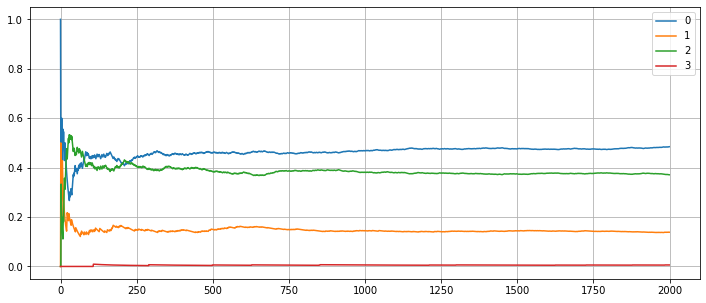

In [38]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

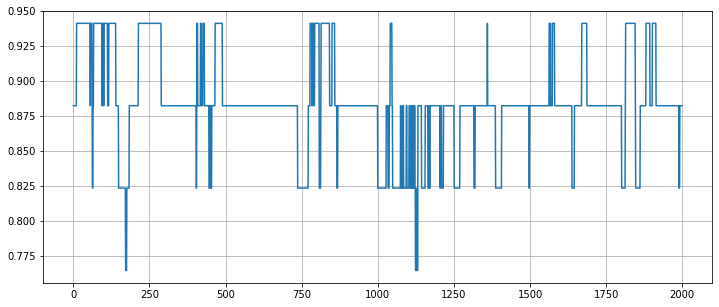

In [39]:
plt.figure(figsize=(12, 5))
sns.lineplot(quality_list)
_ = plt.grid()

In [60]:
val_agents_info = []
for x in agents_info:
    x = dict(x)
    x['train'] = False
    x['eps'] = 0
    val_agents_info.append(x)
val_agents_info[0]['strategy'] = trainer.agents[0].strategy

In [61]:
val_trainer = Trainer(num_experiments=30, agents_info=val_agents_info, can_wait=True, league_level=3, reward_for_win=100)

In [62]:
reward_list = []
quality_list = []

for i in tqdm(range(val_trainer.num_experiments)):
    rollout_rewards = val_trainer.play_rollout()
    reward_list.append(rollout_rewards)
    quality_list.append(val_trainer.agents[0].check_policy())

100%|██████████| 30/30 [00:18<00:00,  1.62it/s]


In [63]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [64]:
winner_list = np.argmax(total_reward_list, 1)

In [65]:
Counter(winner_list)

Counter({0: 12, 2: 11, 1: 5, 3: 2})

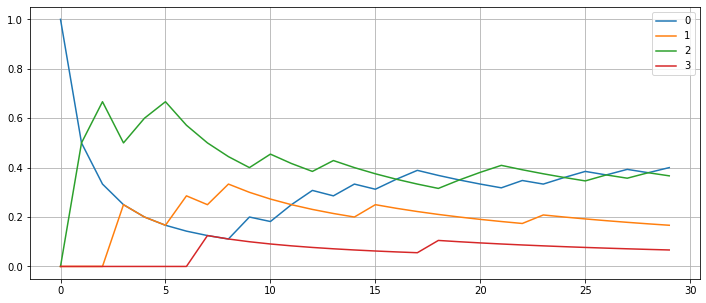

In [66]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [47]:
val_trainer.agents[0].check_policy()

0.8823529411764706

In [48]:
training_pi = trainer.agents[0].strategy

In [49]:
len([k for k in training_pi.Q.keys()])

2465

In [50]:
# new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 6)]
new_keys = list(training_pi.Q.keys())

In [51]:
len(new_keys)

2465

In [52]:
data1 = pkl.dumps(np.array(list(training_pi.Q[k] for k in new_keys), dtype='float16'))
data2 = pkl.dumps(list(new_keys))

In [53]:
len(base64.b64encode(zlib.compress(data1, level=9)))

30940

In [54]:
len(base64.b64encode(zlib.compress(data2, level=9)))

30768

In [55]:
model_dir = f"../output/{datetime.now()}"
date, time = model_dir.split()
try:
    os.mkdir(date, )
except:
    pass
os.mkdir(f"{date}/{time}")
with open(f"{date}/{time}/data1.pkl", "wb") as f:
    f.write(data1)
with open(f"{date}/{time}/data2.pkl", "wb") as f:
    f.write(data2)

In [56]:
print(f"{date}/{time}")

../output/2025-05-02/00:28:43.993020


In [57]:
with open('../src/game/template.py') as f:
    lines = f.readlines()

In [58]:
with open('../src/game/template_submit.py', 'w') as f:
    for line in lines:
        line = line.replace("b'data1data1data1'", str(base64.b64encode(zlib.compress(data1, level=9))))
        line = line.replace("b'data2data2data2'", str(base64.b64encode(zlib.compress(data2, level=9))))
        f.write(line)

In [59]:
!ls -lh ../src/game/template_submit.py

-rw-r--r--  1 aleksei  staff    67K  2 май 00:28 ../src/game/template_submit.py
